<a href="https://colab.research.google.com/github/gabomna/MNA/blob/main/final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Image Enhancement Proposal
## Demo de ecualizacion global, por mosaicos, SWAHE y CLAHE

Retomamos el ejercicio `2_image_enhancement.ipynb` para observar como cambia una imagen al ecualizarla completa, por bloques o mediante vecindades locales. Cada metodo recibe una sola imagen y muestra la entrada junto a su resultado.

### Contenido
1. Fundamento y referencias.
2. Configuracion y lectura de imagenes locales.
3. HE global como referencia.
4. Tile-Based HE con dos tamanos de mosaico.
5. SWAHE sobre dos imagenes.
6. CLAHE sobre dos imagenes, comparado con HE global.

## 1. Fundamento y referencias bibliograficas

El capitulo 3 de Gonzalez y Woods [1] explica los histogramas y las transformaciones de intensidad que usamos aqui. El capitulo 9 trata morfologia: aunque tambien trabaja con vecindades, la ecualizacion local no es una operacion morfologica. Pizer et al. [2] y Zuiderveld [3] desarrollan AHE y CLAHE; OpenCV [4, 5] documenta las funciones empleadas en la demo.

### Del histograma a la imagen

El histograma $h(k)$ cuenta los pixeles con intensidad $k$. Para una imagen o ventana de $N$ pixeles, su acumulado es:

$$C(k)=\sum_{j=0}^{k}h(j),\qquad F(k)=\frac{C(k)}{N}.$$

La ecualizacion clasica usa $255F(k)$. HE global, los mosaicos y SWAHE usan aqui `cv2.equalizeHist`, cuya normalizacion resta el primer acumulado no nulo, $C_{min}$:

$$T(k)\approx\operatorname{round}\left[255\frac{C(k)-C_{min}}{N-C_{min}}\right].$$

Una region constante conserva su nivel. CLAHE sigue otra normalizacion y limita el histograma antes de transformar. Un histograma ecualizado no necesariamente queda uniforme; mas contraste tampoco significa siempre mejor calidad, pues puede resaltar ruido.

### Bibliografia

[1] Gonzalez, R. C., & Woods, R. E. (2018). *Digital Image Processing*, 4th ed. Pearson. Capitulos 3 y 9. [Sitio del libro](https://www.imageprocessingplace.com/DIP-4E/dip4e_main_page.htm).

[2] Pizer, S. M., et al. (1987). Adaptive histogram equalization and its variations. *Computer Vision, Graphics, and Image Processing, 39*(3), 355-368. [DOI](https://doi.org/10.1016/S0734-189X(87)80186-X).

[3] Zuiderveld, K. (1994). Contrast Limited Adaptive Histogram Equalization. En *Graphics Gems IV*, pp. 474-485. Academic Press. [DOI](https://doi.org/10.1016/B978-0-12-336156-1.50061-6).

[4] OpenCV. [Histograms - 2: Histogram Equalization](https://docs.opencv.org/4.x/d5/daf/tutorial_py_histogram_equalization.html).

[5] OpenCV. [cv::CLAHE Class Reference](https://docs.opencv.org/4.x/d6/db6/classcv_1_1CLAHE.html).

## 2. Configuracion e imagenes locales

Se cargan librerias locale

In [ ]:
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageOps

# Limite de tamaño máximo para reducir imagenes y mantener eficiencia en SWAHE.
MAX_SIDE = 128

### Convenciones de la demo

Convertimos cada imagen a escala de grises de 8 bits (`uint8`) y reducimos su lado mayor a un maximo de 128 pixeles, sin ampliarla ni cambiar su proporcion. Esto mantiene manejable el recorrido pixel a pixel de SWAHE; los tamños de ventana se refieren a la imagen reducida.

En cada comparacion, **Original** es esa entrada en gris, antes de ecualizar. Todos los paneles usan la escala fija 0..255. Debajo de cada imagen se muestra su propio histograma y curva CDF; los histogramas comparten la misma escala vertical para facilitar la comparacion. Las funciones de los metodos reciben una matriz 2D, no una lista de imagenes ni canales RGB.

In [ ]:
def load_image(image_path):
    """
    Carga una imagen desde una ruta indicada y la convierte a escala de grises.

    Parametros:
        image_path (str o Path): Ruta a la imagen.

    Retorna:
        np.ndarray: Matriz 2D uint8 con la imagen en escala de grises, lado maximo MAX_SIDE px.

    Notas:
        - Respeta la orientacion EXIF de la foto original.
        - Reduce el lado maximo a MAX_SIDE sin ampliar ni cambiar la proporcion.
        - La salida es siempre uint8 (0-255).
    """
    image_path = Path(image_path)
    with Image.open(image_path) as image_file:
        # Respetamos la orientacion de la foto y limitamos su tamano para que SWAHE no tarde demasiado.
        gray_image = ImageOps.exif_transpose(image_file).convert('L')
        gray_image.thumbnail((MAX_SIDE, MAX_SIDE), Image.Resampling.LANCZOS)
        return np.array(gray_image, dtype=np.uint8)


def show_images(images, title):
    """
    Visualiza cada imagen con su histograma y funcion de distribucion acumulada.

    Parametros:
        images (dict): Diccionario {etiqueta: matriz_imagen} donde cada matriz es 2D uint8.
        title (str): Titulo de la figura.

    Notas:
        - Las imagenes usan escala fija (vmin=0, vmax=255).
        - Cada histograma y CDF aparece debajo de su imagen correspondiente.
        - Los histogramas comparten la misma escala vertical para facilitar la comparacion.
    """
    figure = plt.figure(figsize=(4 * len(images), 7))
    grid = figure.add_gridspec(2, len(images), height_ratios=(2, 1))
    intensity_levels = np.arange(256)
    color_map = plt.get_cmap('tab10')
    max_histogram_count = max(
        np.bincount(image.ravel(), minlength=256).max()
        for image in images.values()
    )

    for column, (label, image) in enumerate(images.items()):
        image_axis = figure.add_subplot(grid[0, column])
        image_axis.imshow(image, cmap='gray', vmin=0, vmax=255)
        image_axis.set_title(label, fontsize=10)
        image_axis.axis('off')

        histogram_axis = figure.add_subplot(grid[1, column])
        cdf_axis = histogram_axis.twinx()
        counts = np.bincount(image.ravel(), minlength=256)
        bars = histogram_axis.bar(
            intensity_levels, counts, width=1.0, alpha=0.35, color=color_map(0)
        )
        cumulative_distribution = np.cumsum(counts) / counts.sum()
        cdf_line, = cdf_axis.plot(
            intensity_levels, cumulative_distribution, color=color_map(1), linewidth=1.5
        )

        histogram_axis.set_xlim(0, 255)
        histogram_axis.set_ylim(0, max_histogram_count * 1.05)
        histogram_axis.set_xlabel('Intensidad')
        histogram_axis.set_ylabel('Pixeles por bin')
        cdf_axis.set_ylim(0, 1)
        cdf_axis.set_ylabel('CDF')
        histogram_axis.legend(
            [bars, cdf_line], ['Histograma', 'CDF'], loc='upper left', fontsize=8
        )

    figure.suptitle(title)
    figure.tight_layout(rect=(0, 0, 1, 0.95))
    plt.show()
    plt.close(figure)

## 3. Ecualizacion global como referencia

Empezamos con `cv2.equalizeHist`: una sola transformacion calculada con el histograma de toda la imagen. Esta referencia permite ver que cambia cuando adaptamos el contraste a cada zona.

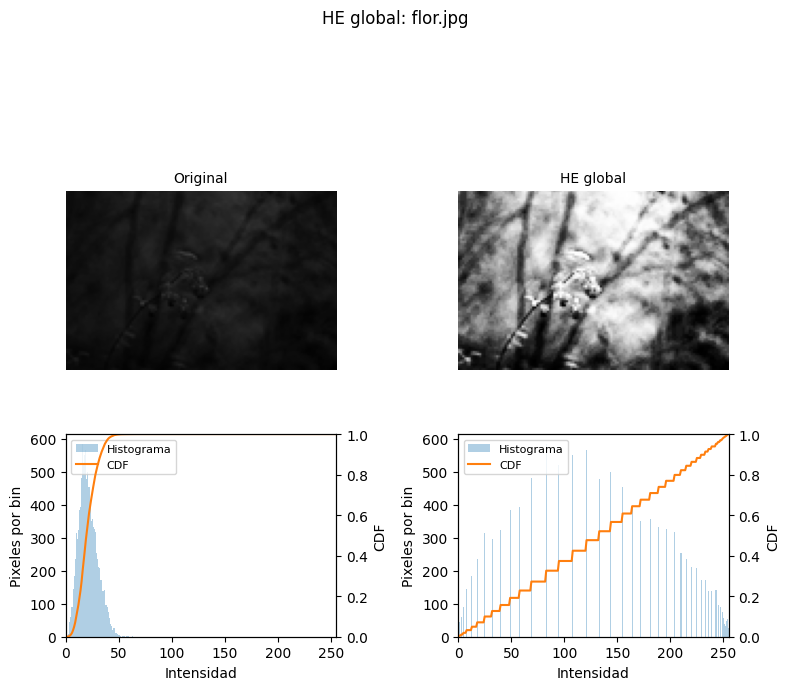

In [ ]:
IMAGE_PATH = 'data/flor.jpg'
global_image = load_image(IMAGE_PATH)
show_images(
    {'Original': global_image, 'HE global': cv2.equalizeHist(global_image)},
    f'HE global: {Path(IMAGE_PATH).name}',
)

## 4. Tile-Based Histogram Equalization

Dividimos una imagen en mosaicos no solapados y aplicamos HE de forma independiente en cada bloque. Conservamos los bloques parciales del borde y el tamano de salida. Probamos lados de **16 y 32 pixeles** sobre la misma entrada.

El tamaño del mosaico implica un compromiso entre adaptación local y costo computacional. Los mosaicos pequeños producen más bloques, por lo que hay más histogramas y transformaciones independientes que calcular; los grandes reducen ese trabajo, pero representan regiones más amplias y se adaptan menos a sus variaciones locales. Como cada bloque usa una transformación distinta, pueden aparecer cambios de contraste en sus fronteras. Se pueden suavizar interpolando las transformaciones de mosaicos vecinos, como hace CLAHE.

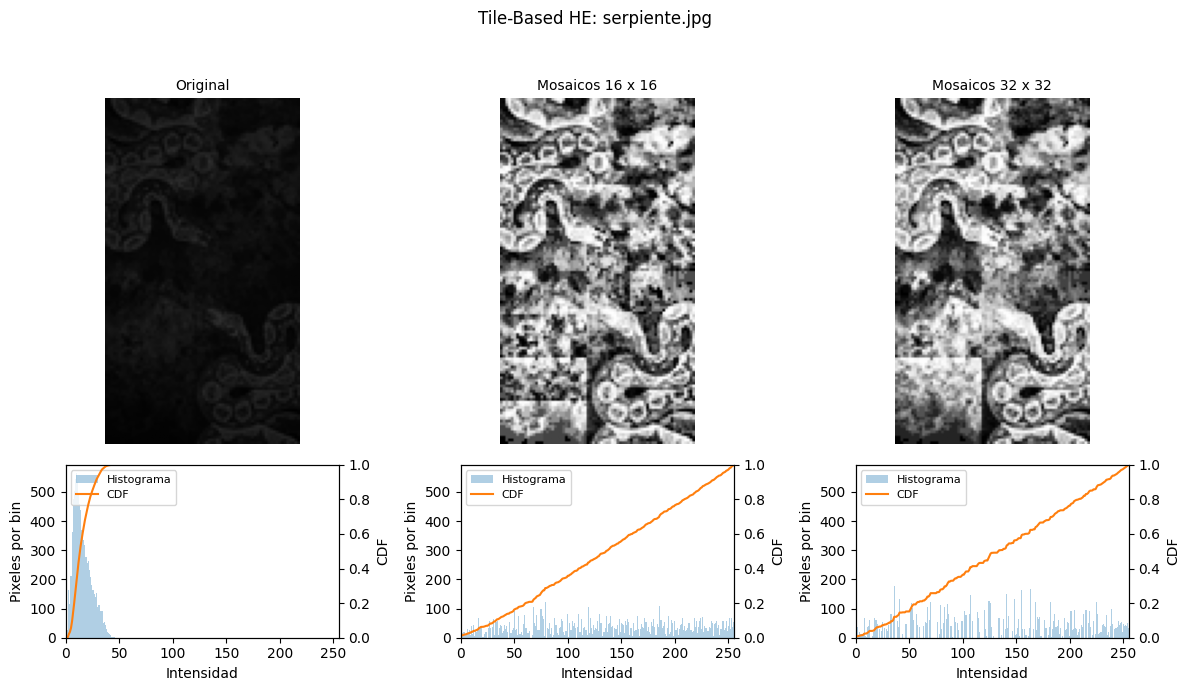

In [ ]:
def tile_he(image, tile_size=16):
    """
    Ecualizacion de histograma por mosaicos (Tile-Based Histogram Equalization).

    Divide la imagen en bloques no solapados y aplica cv2.equalizeHist de forma
    independiente en cada uno. Conserva bloques parciales en el borde.

    Parametros:
        image (np.ndarray): Matriz 2D uint8 de entrada en escala de grises.
        tile_size (int): Lado del mosaico cuadrado en pixeles. Predeterminado: 16.

    Retorna:
        np.ndarray: Imagen ecualized del mismo tamaño que la entrada.

    Levanta:
        ValueError: Si tile_size no es un entero positivo.

    Notas:
        - Mosaicos pequeños se adaptan mas a su zona pero pueden resaltar ruido.
        - Las fronteras entre mosaicos pueden mostrar discontinuidades porque cada
          bloque tiene su propia transformacion de histograma.
        - Mejora futura: interpolar las transformaciones entre mosaicos vecinos.
    """
    if not isinstance(tile_size, int) or tile_size < 1:
        raise ValueError('tile_size debe ser un entero positivo.')
    output = np.empty_like(image)
    height, width = image.shape
    for top in range(0, height, tile_size):
        for left in range(0, width, tile_size):
            # Los cortes de NumPy conservan tambien los bloques mas pequenos del borde.
            tile = image[top:top + tile_size, left:left + tile_size]
            output[top:top + tile_size, left:left + tile_size] = cv2.equalizeHist(tile)
    return output


TILE_IMAGE_PATH = 'data/serpiente.jpg'
tile_image = load_image(TILE_IMAGE_PATH)
show_images(
    {
        'Original': tile_image,
        'Mosaicos 16 x 16': tile_he(tile_image, 16),
        'Mosaicos 32 x 32': tile_he(tile_image, 32),
    },
    f'Tile-Based HE: {Path(TILE_IMAGE_PATH).name}',
)

## 5. Sliding Window Adaptive Histogram Equalization (SWAHE)

Cada pixel usa el histograma de una ventana centrada en el. Recorremos la imagen de uno en uno, ecualizamos la ventana con `cv2.equalizeHist` y conservamos **solo el valor central**. Las ventanas se solapan; en los bordes reflejamos la imagen con `symmetric`.

Usamos una ventana impar de 15 x 15 y dos fotografias locales: bajo contraste e iluminacion desigual. Cada llamada recibe una sola imagen. Esta version recalcula cada ventana, por lo que puede tardar; no incluye optimizaciones. Observa los detalles y el ruido: no tener fronteras fijas de mosaicos no garantiza una mejor imagen.

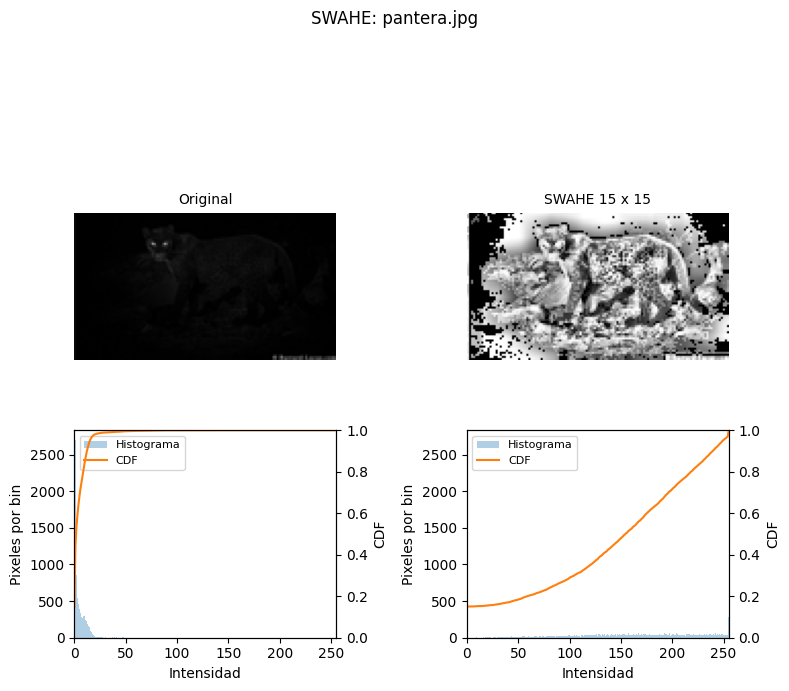

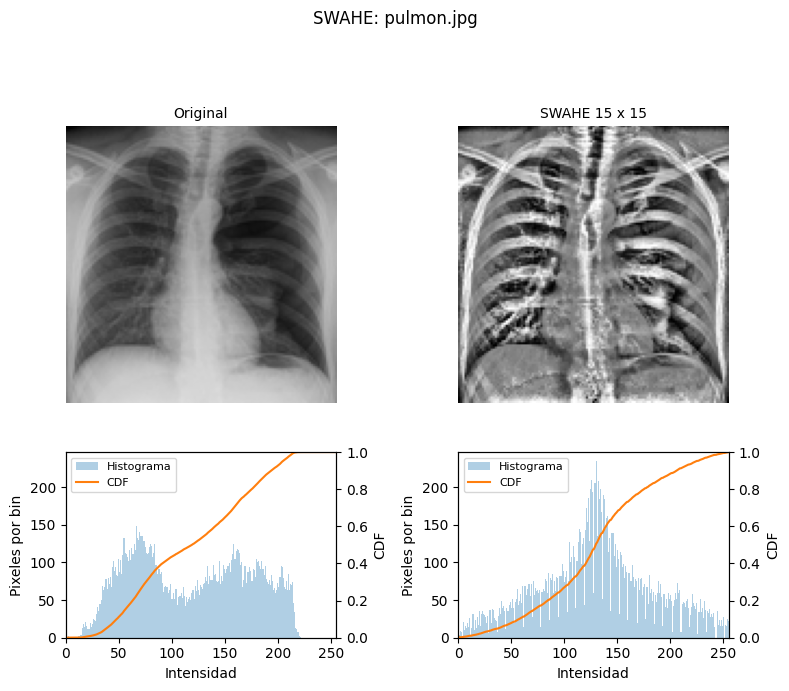

In [ ]:
def swahe(image, window_size=15):
    if not isinstance(window_size, int) or window_size < 1 or window_size % 2 == 0:
        raise ValueError('window_size debe ser un entero positivo e impar.')
    radius = window_size // 2
    # El reflejo da una ventana completa tambien a los pixeles del borde.
    padded = np.pad(image, ((radius, radius), (radius, radius)), mode='symmetric')
    output = np.empty_like(image)
    for row_index in range(image.shape[0]):
        for col_index in range(image.shape[1]):
            window = padded[row_index:row_index + window_size, col_index:col_index + window_size]
            # Ecualizamos toda la ventana, pero solo guardamos su pixel central.
            output[row_index, col_index] = cv2.equalizeHist(window)[radius, radius]
    return output


SWAHE_IMAGE_PATHS = ('data/pantera.jpg', 'data/pulmon.jpg')
for image_path in SWAHE_IMAGE_PATHS:
    image = load_image(image_path)
    show_images(
        {'Original': image, 'SWAHE 15 x 15': swahe(image, 15)},
        f'SWAHE: {Path(image_path).name}',
    )

## 6. CLAHE con OpenCV

La ecualizacion adaptativa puede amplificar ruido en zonas casi uniformes. **Contrast Limited Adaptive Histogram Equalization** limita las frecuencias altas de cada histograma local, redistribuye el exceso y construye las transformaciones acumuladas. Despues interpola entre mosaicos para suavizar las transiciones. El recorte limita la ganancia de contraste, pero no elimina el ruido.

Usamos `cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))`. En OpenCV, la rejilla indica el **numero de mosaicos**, no su tamano en pixeles; `clipLimit` es un limite normalizado, no un porcentaje. Es una configuracion de ejemplo, no un optimo demostrado.

Para cada una de las dos fotografias, comparamos **Original, HE global y CLAHE**. Revisa tanto las sombras y los detalles como el ruido y la naturalidad del contraste. La comparacion usa la misma entrada y escala de visualizacion; queda pendiente ejecutarla con tus imagenes.

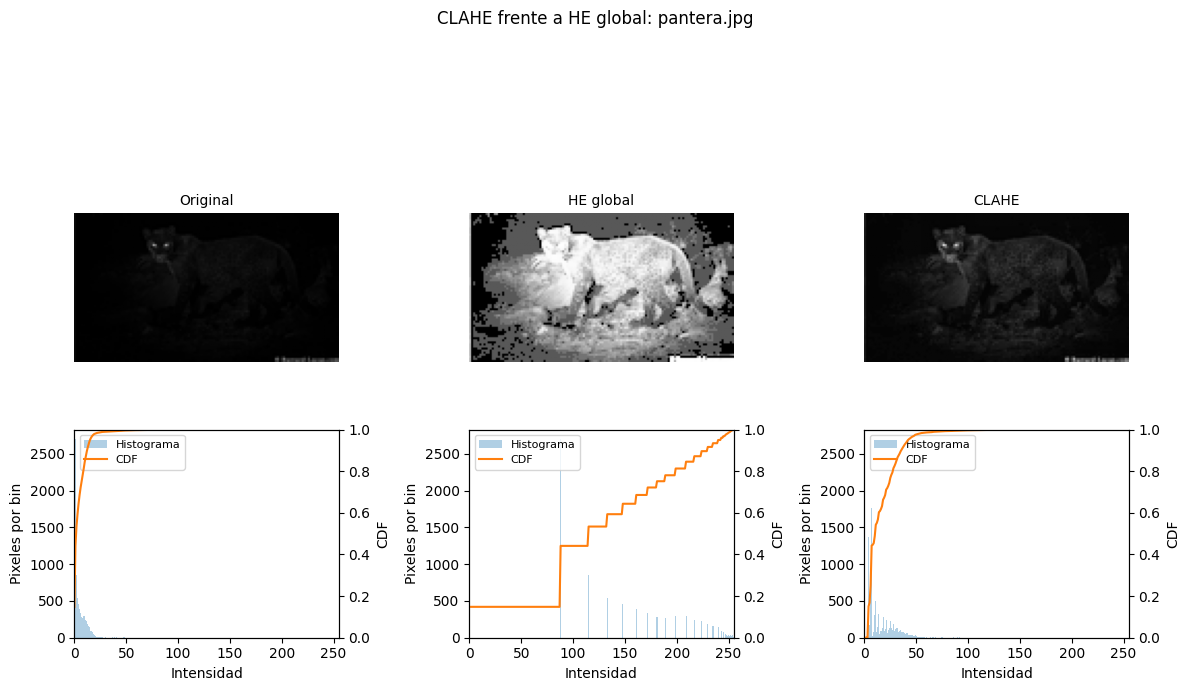

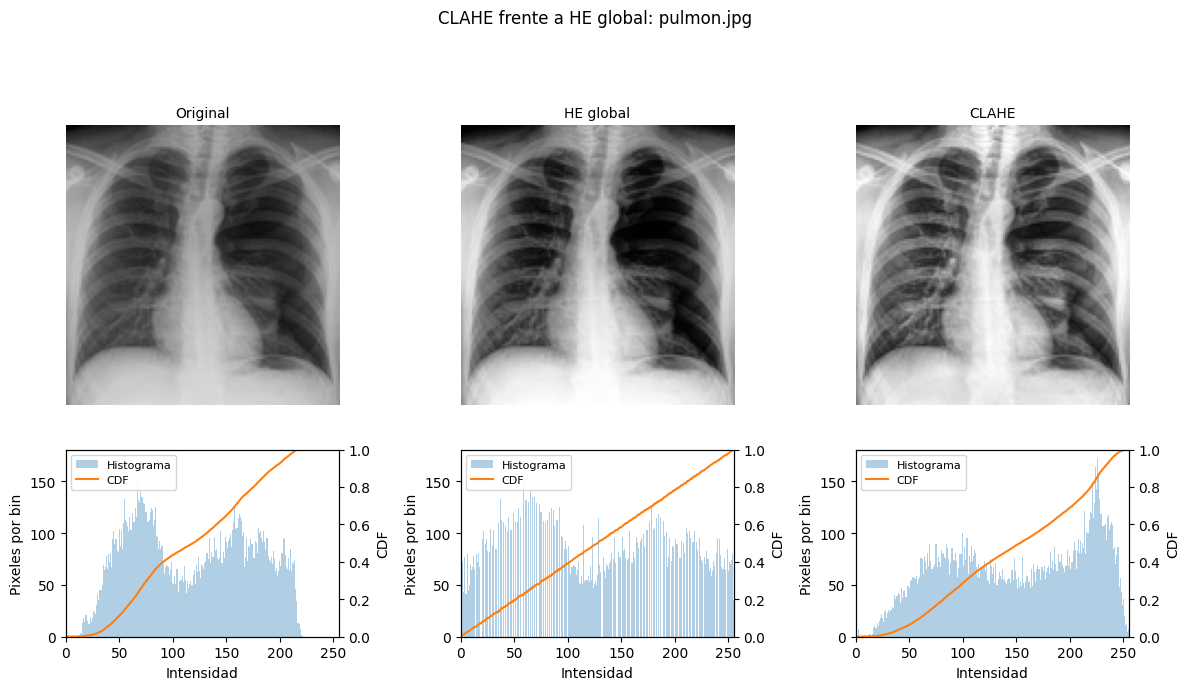

In [ ]:
def clahe_he(image):
    # La rejilla cuenta mosaicos por eje, no pixeles; clipLimit frena la ganancia de contraste.
    operator = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    return operator.apply(image)


CLAHE_IMAGE_PATHS = ('data/pantera.jpg', 'data/pulmon.jpg')
for image_path in CLAHE_IMAGE_PATHS:
    image = load_image(image_path)
    show_images(
        {
            'Original': image,
            'HE global': cv2.equalizeHist(image),
            'CLAHE': clahe_he(image),
        },
        f'CLAHE frente a HE global: {Path(image_path).name}',
    )